# Google Colab Lab Assignment – Pretrained Models

## Research Paper Implementation with Pre-trained Models

**Course Name:** Generative AI Lab

**Lab Title:** Bird Species Image Classification Using Deep Learning – Comparative Analysis of Custom CNN, MobileNetV2 and ResNet50  
**Student Name & PRN:**

Sakshi Walunj- 202502110007

Dhanashri Shah- 202502110008

Shreya Bhosale- 202502110010

**Class:** T.Y.B.Tech  
**Department:** CSE (AI & ML)  

**Dataset:** CUB-200-2011  

### Aim
To study a research paper on fine-grained bird-species image classification and implement a reproducible deep-learning pipeline using a CNN trained from scratch and two ImageNet-pretrained models: **MobileNetV2** and **ResNet50**.

### Important distinction
The supplied research paper evaluates **MobileNet and InceptionV3**. ResNet50 is added in this notebook as an **additional pretrained comparison model** because the practical requires two pretrained models. The notebook does not claim that the research paper used ResNet50 in its own experiment.


# Research Paper Study and Implementation Reference

## Selected Research Paper

**Title:** Enhanced Bird Species Image Recognition and Classification using MobileNet and InceptionV3 Transfer learning Architectures  
**Authors:** Sakthi Priya G., Vignesh Saravanan K., and Dheetchana K.  
**Journal:** *Electronic Letters on Computer Vision and Image Analysis*, 24(1), 118–133, 2025  
**Received:** 20 October 2024  |  **Accepted:** 1 May 2025  

### Paper focus
The paper studies transfer learning for fine-grained bird-species recognition using the **CUB-200-2011** dataset. It focuses on **MobileNet** and **InceptionV3**, with emphasis on accuracy, loss, precision/recall/F1 behaviour, computational efficiency and practical wildlife-conservation deployment. The paper reports **74.60% MobileNet accuracy** and discusses MobileNet as a lightweight alternative for resource-constrained applications.

### Research motivation
Fine-grained bird classification is difficult because different species can have very similar colours, shapes, poses and visual patterns. The paper motivates deep learning and transfer learning as ways to extract useful visual features while reducing the amount of task-specific training required.

### Paper methodology incorporated in this notebook
- CUB-200-2011 fine-grained bird classification.
- Image resizing and normalization.
- Data augmentation using rotation, flipping, scaling/zooming and translation.
- ImageNet-pretrained transfer learning.
- Frozen feature-extraction stage followed by controlled fine-tuning.
- Evaluation using accuracy, loss, precision, recall and F1-score.
- Analysis of model complexity and deployment suitability.

### Reported paper result used for reference
The paper reports **74.60% accuracy for MobileNet** and a MobileNet loss of **0.8685**. The paper also reports an InceptionV3 result, but its document contains an inconsistency: the abstract states 64.00%, while the Results section reports 65.56%. This notebook therefore uses the paper's MobileNet result as the primary paper reference and does not treat the conflicting InceptionV3 value as an experimental target.

**Research paper PDF:** Supplied with this assignment.


# Objective

1. Study the supplied research paper on bird-species image classification.
2. Download and prepare the CUB-200-2011 dataset.
3. Understand fine-grained image-classification challenges.
4. Implement a **Custom CNN from scratch** as a baseline.
5. Implement **MobileNetV2 with ImageNet pretrained weights**.
6. Implement **ResNet50 with ImageNet pretrained weights** as an additional comparison model.
7. Freeze pretrained layers and train task-specific classification heads.
8. Fine-tune the final layers using a smaller learning rate.
9. Visualize training/validation curves and intermediate feature maps.
10. Optimize an important hyperparameter such as learning rate.
11. Evaluate all three models using accuracy, precision, recall, F1-score and test loss.
12. Generate confusion matrices and sample predictions.
13. Compare the executed MobileNetV2 result with the supplied research-paper result without fabricating results.
14. Discuss limitations, computational trade-offs and possible improvements.


# Task 1: Research Paper Selection and Dataset Preparation

## 1.1 Dataset

This implementation uses the **CUB-200-2011 (Caltech-UCSD Birds-200-2011)** dataset for fine-grained bird species classification.

- **Total images:** 11,788
- **Bird species/classes:** 200
- **Official training images:** 5,994
- **Official test images:** 5,794
- **Input size:** 224 × 224 × 3 RGB

### Dataset source provided for this assignment
https://www.kaggle.com/datasets/wenewone/cub2002011?resource=download

### Dataset split used in this notebook
The official CUB training/test partition is preserved. The 5,994 official training images are further split into:

- **5,094 training images**
- **900 validation images**
- **5,794 official test images**

The official test set remains completely unseen during model training and hyperparameter tuning.


## 1.2 Research Paper – Methodology and Our Extension

The supplied paper describes MobileNet as a lightweight CNN that uses depthwise separable convolutions to reduce computation. It uses ImageNet pretrained weights, freezes the convolutional base initially, adds task-specific classification layers and then performs fine-tuning with a reduced learning rate.

### Our implementation

| Component | Implementation |
|---|---|
| Baseline | Custom CNN from scratch |
| Pretrained model 1 | MobileNetV2 – ImageNet |
| Pretrained model 2 | ResNet50 – ImageNet |
| Number of classes | 200 |
| Input | 224×224 RGB |
| Optimizer | Adam |
| Head learning rate | 1e-4 |
| Fine-tuning learning rate | 1e-5 |
| Maximum head epochs | 30 |
| Maximum fine-tuning epochs | 15 |
| Batch size | 16 |
| Regularization | Dropout + data augmentation + early stopping |

**Note:** ResNet50 is an added comparison model. The supplied paper itself compares MobileNet and InceptionV3, not ResNet50.


## 1.3 Environment Setup

The notebook is designed for **Google Colab with GPU runtime**. TensorFlow is used from the Colab environment instead of installing the obsolete `tensorflow-gpu` package. KaggleHub is used to download the public dataset without requiring a manual `kaggle.json` upload.


In [1]:
# Install only lightweight packages that may not already be available in Colab
!pip -q install -U kagglehub seaborn scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.0 MB/s eta 0:00:00


In [2]:
import os
import gc
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2, ResNet50
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1.4 Download the Dataset

The dataset source supplied for this assignment is the public Kaggle CUB-200-2011 dataset. KaggleHub downloads the dataset into the Colab environment and the following cells automatically locate the CUB metadata files.


In [3]:
import kagglehub

DATASET_SLUG = "wenewone/cub2002011"
DOWNLOAD_DIR = kagglehub.dataset_download(DATASET_SLUG)
print("Downloaded dataset path:", DOWNLOAD_DIR)


Using Colab cache for faster access to the 'cub2002011' dataset.
Downloaded dataset path: /kaggle/input/cub2002011


In [4]:
def find_file(root, filename):
    for current_root, _, files in os.walk(root):
        if filename in files:
            return os.path.join(current_root, filename)
    return None

images_file = find_file(DOWNLOAD_DIR, "images.txt")
classes_file = find_file(DOWNLOAD_DIR, "classes.txt")
labels_file = find_file(DOWNLOAD_DIR, "image_class_labels.txt")
split_file = find_file(DOWNLOAD_DIR, "train_test_split.txt")

required_files = {
    "images.txt": images_file,
    "classes.txt": classes_file,
    "image_class_labels.txt": labels_file,
    "train_test_split.txt": split_file
}

missing = [name for name, path in required_files.items() if path is None]
if missing:
    raise FileNotFoundError(
        "CUB metadata files not found: " + ", ".join(missing)
    )

DATA_DIR = os.path.dirname(images_file)
IMAGE_DIR = os.path.join(DATA_DIR, "images")
print("CUB metadata directory:", DATA_DIR)
print("Images directory exists:", os.path.isdir(IMAGE_DIR))


CUB metadata directory: /kaggle/input/cub2002011/CUB_200_2011
Images directory exists: True


## 1.5 Build the Image Metadata Table

The CUB metadata files provide image IDs, class IDs, class names and the official train/test split. The following code converts those files into one pandas DataFrame.


In [5]:
class_names = []
with open(classes_file, "r", encoding="utf-8") as f:
    for line in f:
        _, class_name = line.strip().split(" ", 1)
        class_names.append(class_name.replace("_", " "))

labels = {}
with open(labels_file, "r", encoding="utf-8") as f:
    for line in f:
        image_id, class_id = line.strip().split()
        labels[int(image_id)] = int(class_id) - 1

image_data = []
with open(images_file, "r", encoding="utf-8") as f:
    for line in f:
        image_id, image_path = line.strip().split(" ", 1)
        image_data.append({
            "image_id": int(image_id),
            "image_path": os.path.join(IMAGE_DIR, image_path),
            "label": labels[int(image_id)]
        })

df = pd.DataFrame(image_data)

train_id_set = set()
test_id_set = set()
with open(split_file, "r", encoding="utf-8") as f:
    for line in f:
        image_id, is_train = line.strip().split()
        if int(is_train) == 1:
            train_id_set.add(int(image_id))
        else:
            test_id_set.add(int(image_id))

df["split"] = df["image_id"].apply(
    lambda x: "train" if x in train_id_set else "test"
)

print("Total images:", len(df))
print("Number of classes:", len(class_names))
print("Official train:", len(train_id_set))
print("Official test:", len(test_id_set))


Total images: 11788
Number of classes: 200
Official train: 5994
Official test: 5794


### Dataset Verification

The expected CUB-200-2011 metadata counts are checked before model training. If any assertion fails, the notebook stops immediately instead of silently training on an incorrect dataset.


In [6]:
assert len(df) == 11788, f"Expected 11,788 images, found {len(df)}"
assert len(class_names) == 200, f"Expected 200 classes, found {len(class_names)}"
assert len(train_id_set) == 5994, f"Expected 5,994 train images, found {len(train_id_set)}"
assert len(test_id_set) == 5794, f"Expected 5,794 test images, found {len(test_id_set)}"
assert df["image_path"].map(os.path.exists).all(), "At least one image path is missing"
print("Dataset verification passed.")


Dataset verification passed.


## 1.6 Train, Validation and Test Split

The official test set is kept untouched. The official training set is stratified into approximately **85% training and 15% validation**, giving the project split of **5,094 training + 900 validation + 5,794 test** images.


In [7]:
train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

train_df, val_df = train_test_split(
    train_df,
    test_size=900,
    stratify=train_df["label"],
    random_state=SEED
)

print("Training images  :", len(train_df))
print("Validation images:", len(val_df))
print("Testing images   :", len(test_df))
assert len(train_df) == 5094
assert len(val_df) == 900
assert len(test_df) == 5794


Training images  : 5094
Validation images: 900
Testing images   : 5794


## 1.7 Class Distribution

CUB-200-2011 is a fine-grained dataset with approximately similar numbers of images per class. The distribution is visualized to verify that the split preserves broad class coverage.


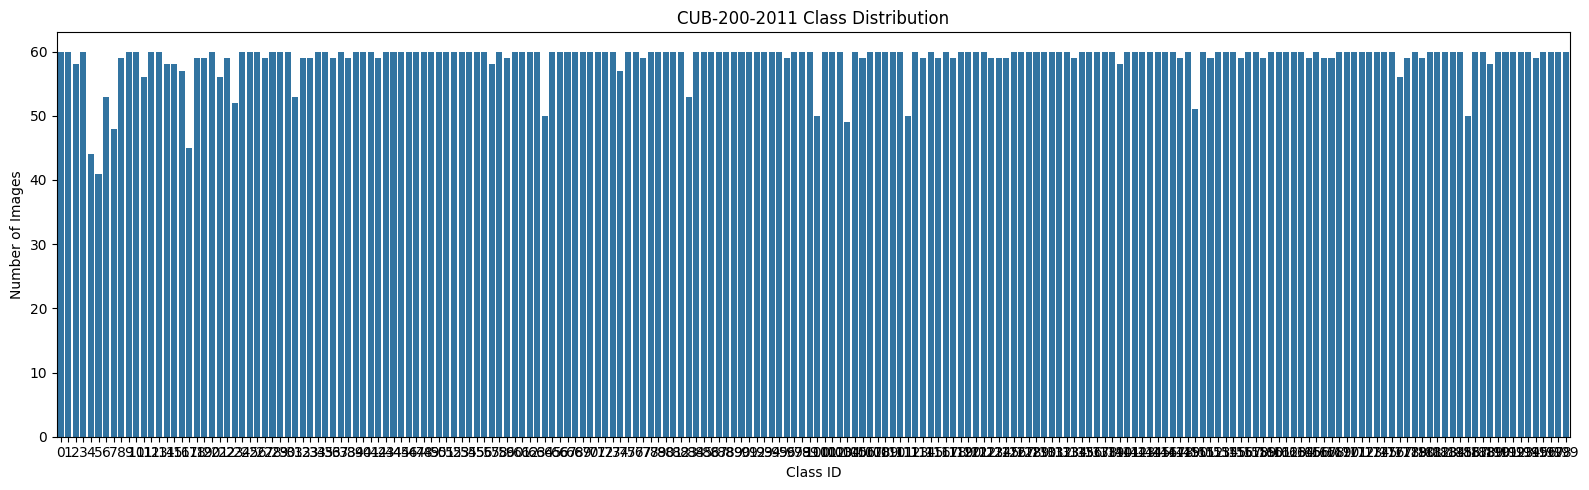

In [8]:
plt.figure(figsize=(16, 5))
sns.countplot(data=df, x="label", order=range(NUM_CLASSES) if "NUM_CLASSES" in globals() else range(200))
plt.title("CUB-200-2011 Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


## 1.8 Sample Images

Full images are used in the main pipeline rather than applying bounding-box cropping. This keeps the implementation consistent with the supplied project reference.


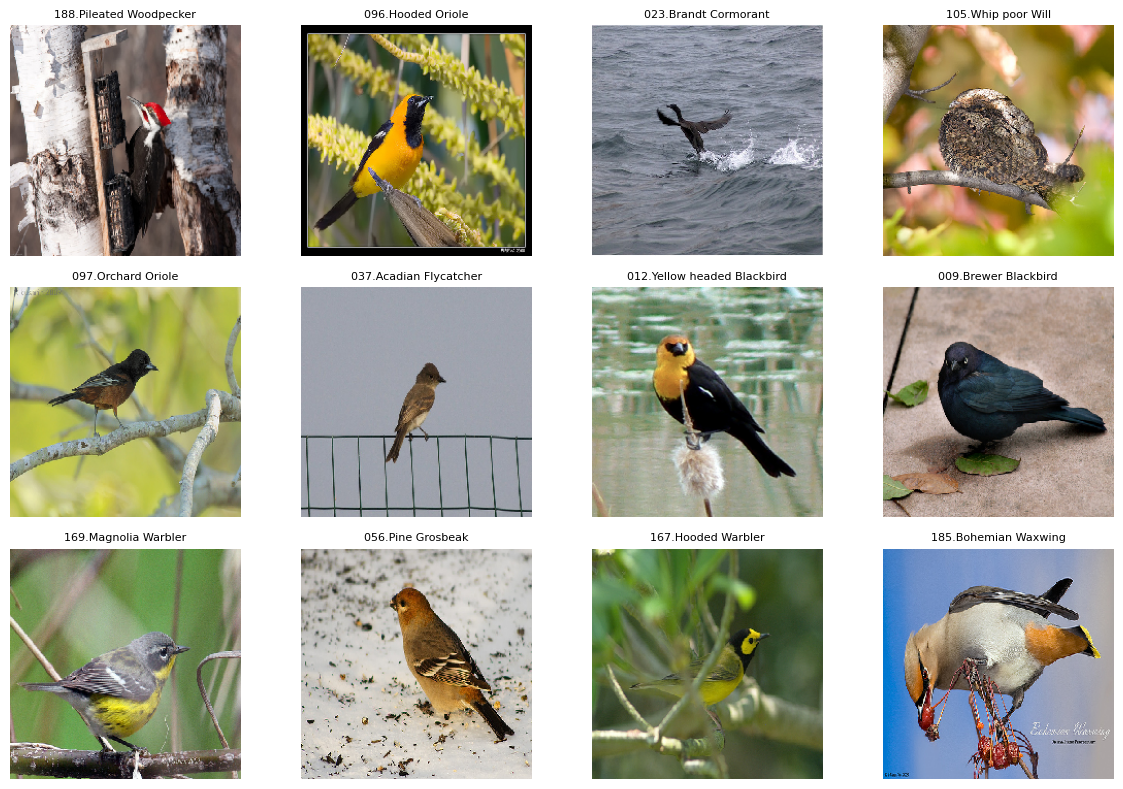

In [9]:
plt.figure(figsize=(12, 8))
sample_df = train_df.sample(12, random_state=SEED)
for i, (_, row) in enumerate(sample_df.iterrows()):
    image = tf.keras.utils.load_img(row["image_path"], target_size=(224, 224))
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(class_names[int(row["label"])], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 1.9 Image Preprocessing and Data Augmentation

The reference project uses **224×224 RGB** input and augmentation including random horizontal flip, rotation, zoom and translation. The supplied research paper also discusses rotation, flipping, scaling/cropping and brightness changes.

Training images are augmented; validation and test images are not augmented. Architecture-specific preprocessing is applied inside each pretrained model so that MobileNetV2 and ResNet50 receive the input representation expected by their ImageNet weights.


In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(class_names)

augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.08, seed=SEED),
    layers.RandomZoom(0.15, seed=SEED),
    layers.RandomTranslation(0.05, 0.05, seed=SEED)
], name="data_augmentation")

def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.int32)

def make_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe["image_path"].values, dataframe["label"].values)
    )
    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2000, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Input size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)


Input size: (224, 224)
Batch size: 16


# Task 2: Model Implementation and Fine-tuning

## 2.1 Custom CNN from Scratch

The Custom CNN is the baseline model. It learns all convolutional features directly from CUB-200-2011 without pretrained weights.


In [11]:
def build_custom_cnn():
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = augmentation(inputs)
    x = layers.Rescaling(1.0 / 255.0)(x)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="Custom_CNN")

custom_cnn = build_custom_cnn()
custom_cnn.summary()


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,293,288 (4.93 MB)

 Trainable params: 1,291,368 (4.93 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 2.2 CNN Training

The project reference specifies Adam, learning rate `3e-4`, sparse categorical cross-entropy, batch size 16 and a maximum of 30 epochs with early stopping.


In [12]:
def make_callbacks(path):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", mode="max", patience=5,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7
        ),
        keras.callbacks.ModelCheckpoint(
            path, monitor="val_accuracy", mode="max",
            save_best_only=True, save_weights_only=True
        )
    ]

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start = time.time()
history_cnn = custom_cnn.fit(
    train_ds, validation_data=val_ds, epochs=30,
    callbacks=make_callbacks("/content/best_custom_cnn.weights.h5"),
    verbose=1
)
cnn_training_time = time.time() - start
custom_cnn.load_weights("/content/best_custom_cnn.weights.h5")
print(f"CNN training time: {cnn_training_time / 60:.2f} minutes")


Epoch 1/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 73s 165ms/step - accuracy: 0.0061 - loss: 5.5324 - val_accuracy: 0.0056 - val_loss: 5.5044 - learning_rate: 3.0000e-04
Epoch 2/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 59s 157ms/step - accuracy: 0.0096 - loss: 5.2937 - val_accuracy: 0.0189 - val_loss: 5.1709 - learning_rate: 3.0000e-04
Epoch 3/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 78s 158ms/step - accuracy: 0.0149 - loss: 5.1819 - val_accuracy: 0.0156 - val_loss: 5.1230 - learning_rate: 3.0000e-04
Epoch 4/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 54s 155ms/step - accuracy: 0.0163 - loss: 5.0896 - val_accuracy: 0.0300 - val_loss: 5.0837 - learning_rate: 3.0000e-04
Epoch 5/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 55s 156ms/step - accuracy: 0.0183 - loss: 5.0256 - val_accuracy: 0.0222 - val_loss: 4.9783 - learning_rate: 3.0000e-04
Epoch 6/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 55s 156ms/step - accuracy: 0.0179 - loss: 4.9460 - val_accuracy: 0.0300 - val_loss: 5.3265 - learning_rate: 3.0000e-04
Epoch 7/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 54s 15

## 2.3 CNN Training Curves


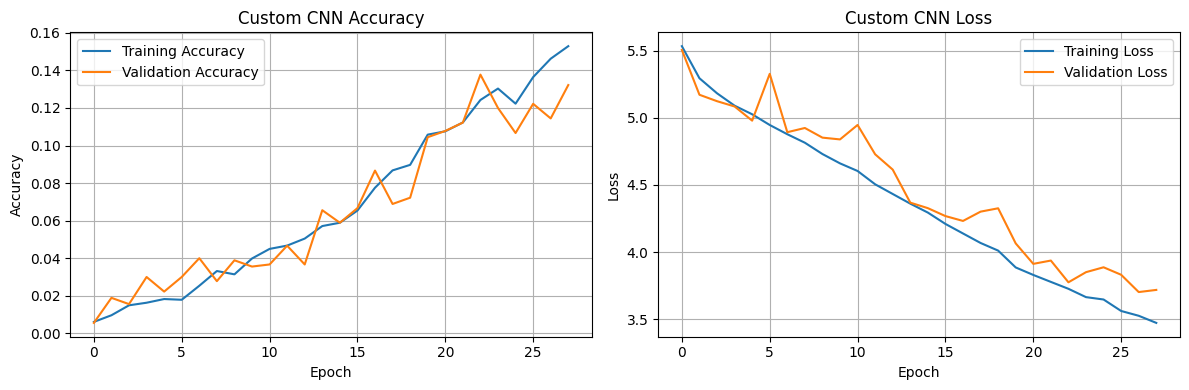

In [13]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="Training Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(title + " Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(history.history["loss"], label="Training Loss")
    axes[1].plot(history.history["val_loss"], label="Validation Loss")
    axes[1].set_title(title + " Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid()
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "Custom CNN")


## 2.4 Pretrained Model 1 – MobileNetV2

MobileNetV2 is used as the lightweight pretrained model. It is initialized with **ImageNet weights**, its convolutional base is frozen during feature extraction, and a new 200-class classification head is trained.


In [14]:
mobilenet_base = MobileNetV2(
    input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet"
)
mobilenet_base.trainable = False

mobilenet_inputs = keras.Input(shape=(*IMG_SIZE, 3), name="mobilenet_input")
mobilenet_x = augmentation(mobilenet_inputs)
mobilenet_x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="mobilenet_preprocess")(mobilenet_x)
mobilenet_x = mobilenet_base(mobilenet_x, training=False)
mobilenet_x = layers.GlobalAveragePooling2D()(mobilenet_x)
mobilenet_x = layers.Dropout(0.3)(mobilenet_x)
mobilenet_x = layers.Dense(256, activation="relu")(mobilenet_x)
mobilenet_x = layers.Dropout(0.3)(mobilenet_x)
mobilenet_outputs = layers.Dense(NUM_CLASSES, activation="softmax")(mobilenet_x)

mobilenet_model = keras.Model(
    mobilenet_inputs, mobilenet_outputs, name="MobileNetV2_Bird_Classifier"
)
mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_Bird_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_input (InputLayer)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess            │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,637,320 (10.06 MB)

 Trainable params: 379,336 (1.45 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 2.5 MobileNetV2 – Transfer Learning Phase

Only the newly added classification head is trained while the ImageNet feature extractor remains frozen.


In [15]:
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

start = time.time()
history_mobile_head = mobilenet_model.fit(
    train_ds, validation_data=val_ds, epochs=30,
    callbacks=make_callbacks("/content/best_mobilenet_head.weights.h5"),
    verbose=1
)
mobile_head_time = time.time() - start
mobilenet_model.load_weights("/content/best_mobilenet_head.weights.h5")
print(f"MobileNetV2 feature-extraction time: {mobile_head_time / 60:.2f} minutes")


Epoch 1/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 32s 66ms/step - accuracy: 0.0071 - loss: 5.3640 - val_accuracy: 0.0322 - val_loss: 5.1001 - learning_rate: 1.0000e-04
Epoch 2/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.0334 - loss: 5.0147 - val_accuracy: 0.0878 - val_loss: 4.6983 - learning_rate: 1.0000e-04
Epoch 3/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.0791 - loss: 4.5573 - val_accuracy: 0.1767 - val_loss: 4.1006 - learning_rate: 1.0000e-04
Epoch 4/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.1298 - loss: 4.0915 - val_accuracy: 0.2444 - val_loss: 3.5871 - learning_rate: 1.0000e-04
Epoch 5/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.1837 - loss: 3.6628 - val_accuracy: 0.3067 - val_loss: 3.2388 - learning_rate: 1.0000e-04
Epoch 6/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.2236 - loss: 3.3538 - val_accuracy: 0.3411 - val_loss: 2.9641 - learning_rate: 1.0000e-04
Epoch 7/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/ste

## 2.6 MobileNetV2 – Fine-tuning

The final 30 layers of the pretrained backbone are unfrozen. Batch-normalization layers are kept frozen for stable fine-tuning, and the learning rate is reduced to `1e-5`.


In [16]:
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False
for layer in mobilenet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Trainable MobileNetV2 layers:", sum(int(l.trainable) for l in mobilenet_base.layers))

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

start = time.time()
history_mobile_ft = mobilenet_model.fit(
    train_ds, validation_data=val_ds, epochs=15,
    callbacks=make_callbacks("/content/best_mobilenet_ft.weights.h5"),
    verbose=1
)
mobile_ft_time = time.time() - start
mobilenet_model.load_weights("/content/best_mobilenet_ft.weights.h5")
print(f"MobileNetV2 fine-tuning time: {mobile_ft_time / 60:.2f} minutes")


Trainable MobileNetV2 layers: 19
Epoch 1/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.5887 - loss: 1.4607 - val_accuracy: 0.5211 - val_loss: 1.7244 - learning_rate: 1.0000e-05
Epoch 2/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.6080 - loss: 1.3859 - val_accuracy: 0.5300 - val_loss: 1.7246 - learning_rate: 1.0000e-05
Epoch 3/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.6276 - loss: 1.3192 - val_accuracy: 0.5389 - val_loss: 1.6832 - learning_rate: 1.0000e-05
Epoch 4/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.6378 - loss: 1.2621 - val_accuracy: 0.5233 - val_loss: 1.6869 - learning_rate: 1.0000e-05
Epoch 5/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.6300 - loss: 1.2638 - val_accuracy: 0.5378 - val_loss: 1.6298 - learning_rate: 1.0000e-05
Epoch 6/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.6425 - loss: 1.2441 - val_accuracy: 0.5400 - val_loss: 1.6361 - learning_rate: 1.0000e-05
Epoch 7/15
319/319 

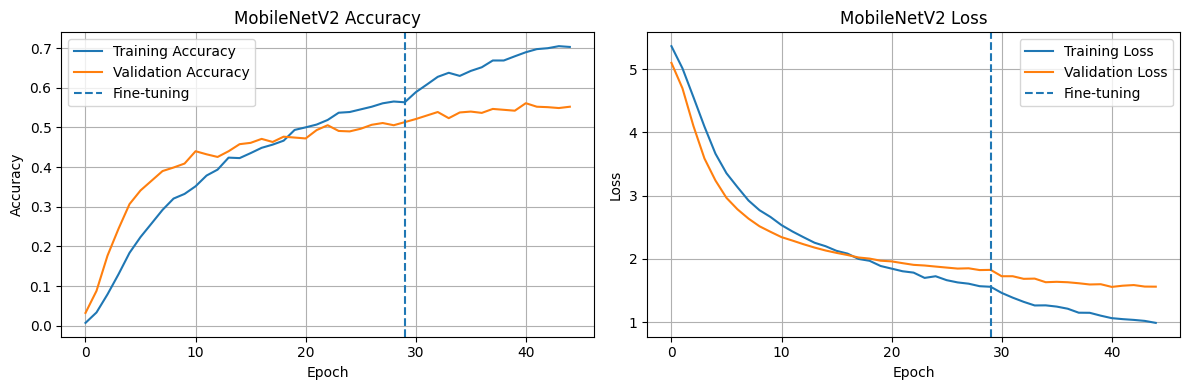

In [17]:
def combine_histories(h1, h2):
    return {
        key: h1.history[key] + h2.history[key]
        for key in ["accuracy", "val_accuracy", "loss", "val_loss"]
    }

mobile_history = combine_histories(history_mobile_head, history_mobile_ft)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mobile_history["accuracy"], label="Training Accuracy")
axes[0].plot(mobile_history["val_accuracy"], label="Validation Accuracy")
axes[0].axvline(len(history_mobile_head.history["accuracy"])-1, linestyle="--", label="Fine-tuning")
axes[0].set_title("MobileNetV2 Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid()
axes[1].plot(mobile_history["loss"], label="Training Loss")
axes[1].plot(mobile_history["val_loss"], label="Validation Loss")
axes[1].axvline(len(history_mobile_head.history["loss"])-1, linestyle="--", label="Fine-tuning")
axes[1].set_title("MobileNetV2 Loss"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid()
plt.tight_layout(); plt.show()


## 2.7 Pretrained Model 2 – ResNet50

ResNet50 is added as the second ImageNet-pretrained model. Residual connections allow the network to learn deeper hierarchical representations while reducing degradation problems during optimization.

**This is our extension to the supplied paper; the paper itself did not use ResNet50 as one of its two main experimental models.**


In [18]:
resnet_base = ResNet50(
    input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet"
)
resnet_base.trainable = False

resnet_inputs = keras.Input(shape=(*IMG_SIZE, 3), name="resnet_input")
resnet_x = augmentation(resnet_inputs)
resnet_x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="resnet_preprocess")(resnet_x)
resnet_x = resnet_base(resnet_x, training=False)
resnet_x = layers.GlobalAveragePooling2D(name="resnet_gap")(resnet_x)
resnet_x = layers.Dropout(0.3)(resnet_x)
resnet_x = layers.Dense(256, activation="relu")(resnet_x)
resnet_x = layers.Dropout(0.3)(resnet_x)
resnet_outputs = layers.Dense(NUM_CLASSES, activation="softmax")(resnet_x)

resnet_model = keras.Model(resnet_inputs, resnet_outputs, name="ResNet50_Bird_Classifier")
resnet_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "ResNet50_Bird_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet_input (InputLayer)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess (Rescaling)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_gap                      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,163,656 (92.18 MB)

 Trainable params: 575,944 (2.20 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 2.8 ResNet50 – Transfer Learning Phase

The ResNet50 convolutional base is frozen while the new classification head is trained.


In [19]:
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

start = time.time()
history_resnet_head = resnet_model.fit(
    train_ds, validation_data=val_ds, epochs=30,
    callbacks=make_callbacks("/content/best_resnet_head.weights.h5"),
    verbose=1
)
resnet_head_time = time.time() - start
resnet_model.load_weights("/content/best_resnet_head.weights.h5")
print(f"ResNet50 feature-extraction time: {resnet_head_time / 60:.2f} minutes")


Epoch 1/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.0041 - loss: 5.4608 - val_accuracy: 0.0056 - val_loss: 5.2989 - learning_rate: 1.0000e-04
Epoch 2/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 35s 93ms/step - accuracy: 0.0041 - loss: 5.3355 - val_accuracy: 0.0100 - val_loss: 5.2962 - learning_rate: 1.0000e-04
Epoch 3/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 33s 90ms/step - accuracy: 0.0059 - loss: 5.3158 - val_accuracy: 0.0089 - val_loss: 5.2943 - learning_rate: 1.0000e-04
Epoch 4/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - accuracy: 0.0061 - loss: 5.3062 - val_accuracy: 0.0100 - val_loss: 5.2951 - learning_rate: 1.0000e-04
Epoch 5/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.0071 - loss: 5.3051 - val_accuracy: 0.0056 - val_loss: 5.2950 - learning_rate: 1.0000e-04
Epoch 6/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 33s 90ms/step - accuracy: 0.0055 - loss: 5.3016 - val_accuracy: 0.0067 - val_loss: 5.2950 - learning_rate: 5.0000e-05
Epoch 7/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 33s 89ms/st

## 2.9 ResNet50 – Fine-tuning

The final 30 ResNet50 layers are made trainable while BatchNormalization layers remain frozen. A smaller learning rate of `1e-5` is used.


In [20]:
resnet_base.trainable = True
for layer in resnet_base.layers[:-30]:
    layer.trainable = False
for layer in resnet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Trainable ResNet50 layers:", sum(int(l.trainable) for l in resnet_base.layers))

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

start = time.time()
history_resnet_ft = resnet_model.fit(
    train_ds, validation_data=val_ds, epochs=15,
    callbacks=make_callbacks("/content/best_resnet_ft.weights.h5"),
    verbose=1
)
resnet_ft_time = time.time() - start
resnet_model.load_weights("/content/best_resnet_ft.weights.h5")
print(f"ResNet50 fine-tuning time: {resnet_ft_time / 60:.2f} minutes")


Trainable ResNet50 layers: 21
Epoch 1/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 54s 127ms/step - accuracy: 0.0079 - loss: 5.3064 - val_accuracy: 0.0067 - val_loss: 5.2961 - learning_rate: 1.0000e-05
Epoch 2/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - accuracy: 0.0079 - loss: 5.2970 - val_accuracy: 0.0111 - val_loss: 5.2952 - learning_rate: 1.0000e-05
Epoch 3/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.0090 - loss: 5.2889 - val_accuracy: 0.0078 - val_loss: 5.2972 - learning_rate: 1.0000e-05
Epoch 4/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 44s 119ms/step - accuracy: 0.0086 - loss: 5.2855 - val_accuracy: 0.0078 - val_loss: 5.2868 - learning_rate: 1.0000e-05
Epoch 5/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.0090 - loss: 5.2787 - val_accuracy: 0.0144 - val_loss: 5.2831 - learning_rate: 1.0000e-05
Epoch 6/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 42s 116ms/step - accuracy: 0.0133 - loss: 5.2649 - val_accuracy: 0.0122 - val_loss: 5.2659 - learning_rate: 1.0000e-05
Epoch 7/15
319/3

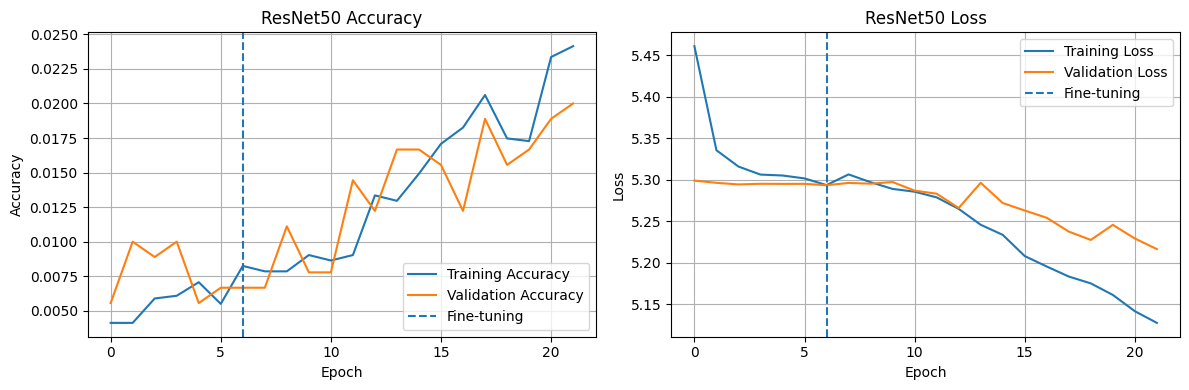

In [21]:
resnet_history = combine_histories(history_resnet_head, history_resnet_ft)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(resnet_history["accuracy"], label="Training Accuracy")
axes[0].plot(resnet_history["val_accuracy"], label="Validation Accuracy")
axes[0].axvline(len(history_resnet_head.history["accuracy"])-1, linestyle="--", label="Fine-tuning")
axes[0].set_title("ResNet50 Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid()
axes[1].plot(resnet_history["loss"], label="Training Loss")
axes[1].plot(resnet_history["val_loss"], label="Validation Loss")
axes[1].axvline(len(history_resnet_head.history["loss"])-1, linestyle="--", label="Fine-tuning")
axes[1].set_title("ResNet50 Loss"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid()
plt.tight_layout(); plt.show()


## 2.10 Feature Map Visualization

Feature maps are visualized from the final convolutional layer of the Custom CNN to demonstrate the spatial patterns learned by the network.


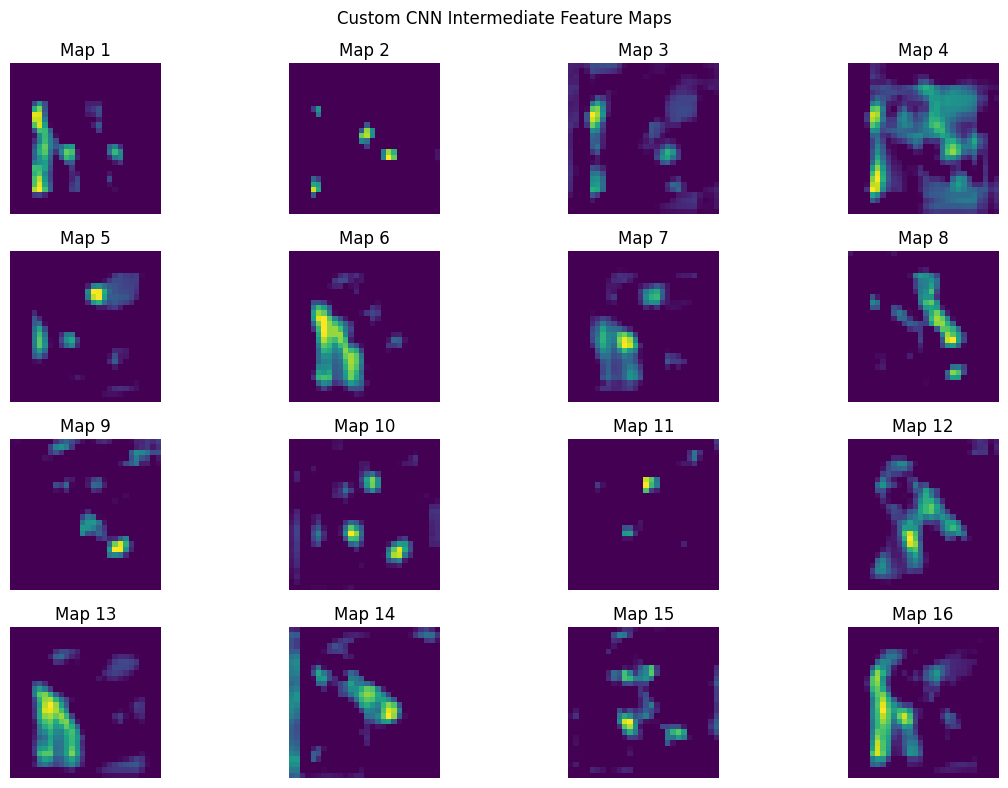

In [22]:
conv_layers = [layer for layer in custom_cnn.layers if isinstance(layer, layers.Conv2D)]
feature_layer = conv_layers[-1]
feature_model = keras.Model(custom_cnn.input, feature_layer.output)

sample_images, _ = next(iter(test_ds))
feature_maps = feature_model.predict(sample_images[:1], verbose=0)
num_maps = min(16, feature_maps.shape[-1])

plt.figure(figsize=(12, 8))
for i in range(num_maps):
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
    plt.axis("off")
    plt.title(f"Map {i+1}")
plt.suptitle("Custom CNN Intermediate Feature Maps")
plt.tight_layout(); plt.show()


## 2.11 Hyperparameter Configuration

| Hyperparameter | Custom CNN | MobileNetV2 | ResNet50 |
|---|---:|---:|---:|
| Input size | 224×224 | 224×224 | 224×224 |
| Batch size | 16 | 16 | 16 |
| Head learning rate | 3e-4 | 1e-4 | 1e-4 |
| Fine-tuning learning rate | — | 1e-5 | 1e-5 |
| Optimizer | Adam | Adam | Adam |
| Maximum head epochs | 30 | 30 | 30 |
| Maximum fine-tuning epochs | — | 15 | 15 |
| Augmentation | Yes | Yes | Yes |
| Pretrained weights | No | ImageNet | ImageNet |

Early stopping and learning-rate reduction are used to avoid unnecessary epochs and reduce overfitting.


## 2.12 Lightweight Learning-Rate Comparison

A small two-epoch experiment compares `1e-3` and `1e-4` for a frozen MobileNetV2 feature extractor. This is a lightweight hyperparameter study; it does not replace the final training configuration.


   Learning Rate  Best Validation Accuracy
0         0.0010                  0.267778
1         0.0001                  0.027778


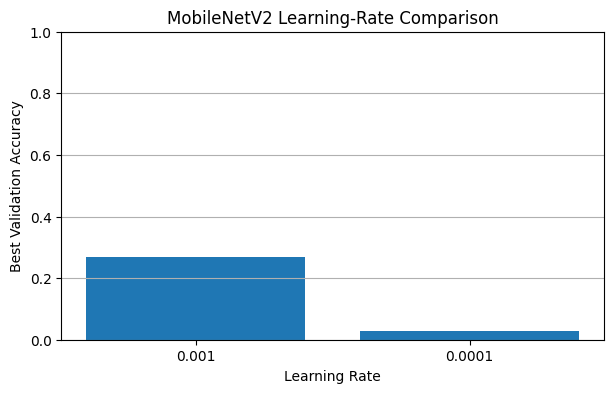

In [23]:
TUNING_SAMPLES = min(800, len(train_df))
tuning_df = train_df.sample(TUNING_SAMPLES, random_state=SEED)
tuning_ds = make_dataset(tuning_df, shuffle=True)
learning_rates = [1e-3, 1e-4]
tuning_results = []

for lr in learning_rates:
    temp_base = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet")
    temp_base.trainable = False
    temp_inputs = keras.Input(shape=(*IMG_SIZE, 3))
    temp_x = layers.Rescaling(1.0 / 127.5, offset=-1.0)(temp_inputs)
    temp_x = temp_base(temp_x, training=False)
    temp_x = layers.GlobalAveragePooling2D()(temp_x)
    temp_outputs = layers.Dense(NUM_CLASSES, activation="softmax")(temp_x)
    temp_model = keras.Model(temp_inputs, temp_outputs)
    temp_model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = temp_model.fit(tuning_ds, validation_data=val_ds, epochs=2, verbose=0)
    tuning_results.append({"Learning Rate": lr, "Best Validation Accuracy": max(hist.history["val_accuracy"])})
    del temp_model, temp_base
    gc.collect()

tuning_results = pd.DataFrame(tuning_results)
print(tuning_results)

plt.figure(figsize=(7, 4))
plt.bar(tuning_results["Learning Rate"].astype(str), tuning_results["Best Validation Accuracy"])
plt.xlabel("Learning Rate"); plt.ylabel("Best Validation Accuracy"); plt.title("MobileNetV2 Learning-Rate Comparison"); plt.ylim(0, 1); plt.grid(axis="y"); plt.show()


# Task 3: Model Evaluation and Performance Comparison

## 3.1 Evaluation Function

All final metrics are calculated on the **unseen official CUB test set**. The notebook never manually enters its own accuracy, precision, recall or F1 values.


In [24]:
def evaluate_model(model, dataset, model_name):
    y_true, y_pred = [], []
    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(probabilities, axis=1))
        y_true.extend(labels.numpy())

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    for key in ["Accuracy", "Precision", "Recall", "F1-Score"]:
        print(f"{key:10s}: {results[key] * 100:.2f}%")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=np.arange(NUM_CLASSES), target_names=class_names, zero_division=0))
    return results, y_true, y_pred

cnn_test_loss, _ = custom_cnn.evaluate(test_ds, verbose=0)
mobile_test_loss, _ = mobilenet_model.evaluate(test_ds, verbose=0)
resnet_test_loss, _ = resnet_model.evaluate(test_ds, verbose=0)

cnn_results, y_true_cnn, y_pred_cnn = evaluate_model(custom_cnn, test_ds, "Custom CNN")
mobilenet_results, y_true_mobilenet, y_pred_mobilenet = evaluate_model(mobilenet_model, test_ds, "MobileNetV2")
resnet_results, y_true_resnet, y_pred_resnet = evaluate_model(resnet_model, test_ds, "ResNet50")


Custom CNN
Accuracy  : 12.89%
Precision : 13.37%
Recall    : 12.89%
F1-Score  : 10.99%

Classification report:
                                    precision    recall  f1-score   support

        001.Black footed Albatross       0.17      0.10      0.12        30
              002.Laysan Albatross       0.04      0.03      0.04        30
               003.Sooty Albatross       0.03      0.07      0.04        28
             004.Groove billed Ani       0.07      0.13      0.09        30
                005.Crested Auklet       0.21      0.21      0.21        14
                  006.Least Auklet       0.09      0.27      0.13        11
               007.Parakeet Auklet       0.19      0.26      0.22        23
             008.Rhinoceros Auklet       0.02      0.06      0.03        18
              009.Brewer Blackbird       0.00      0.00      0.00        29
          010.Red winged Blackbird       0.50      0.47      0.48        30
               011.Rusty Blackbird       0.00      0

## 3.2 Confusion Matrices

A separate 200×200 confusion matrix is generated for each model. Each row represents the actual class and each column represents the predicted class.


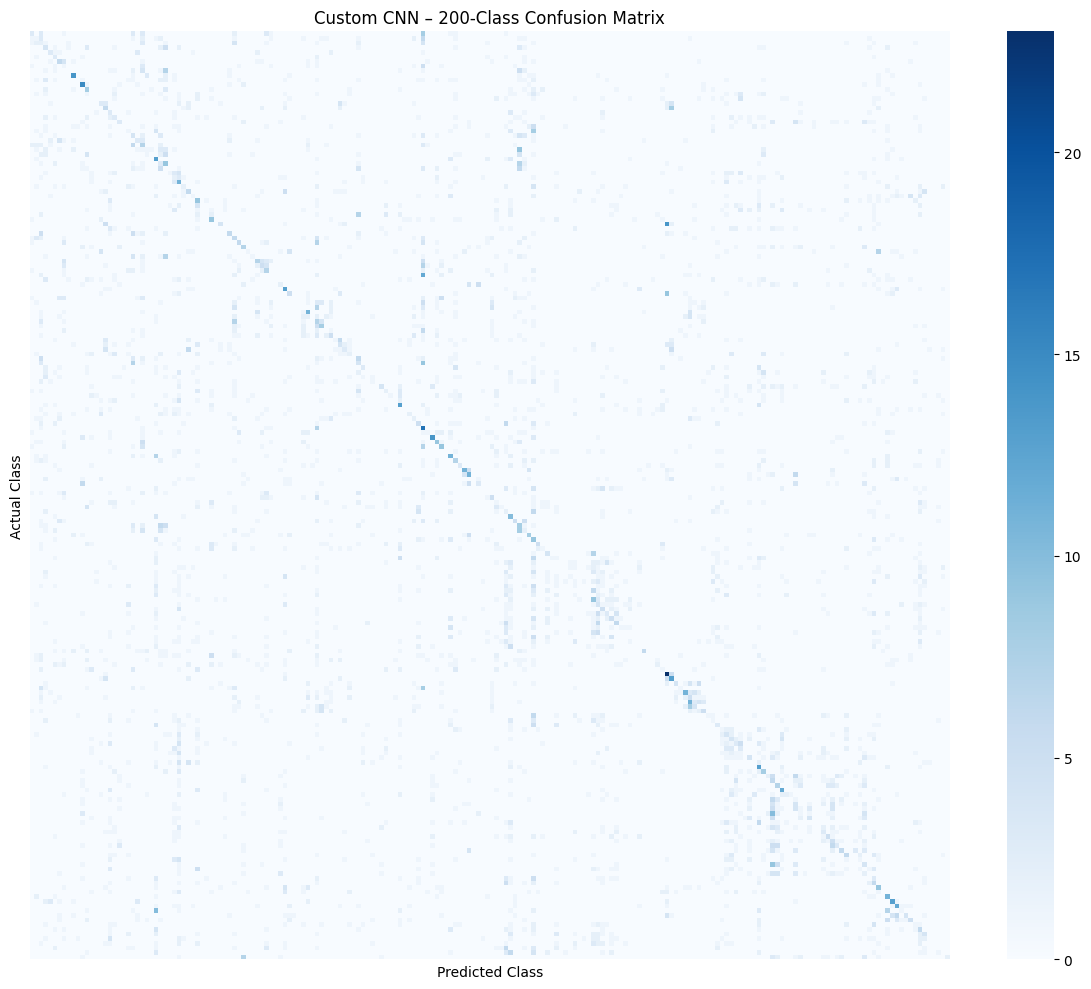

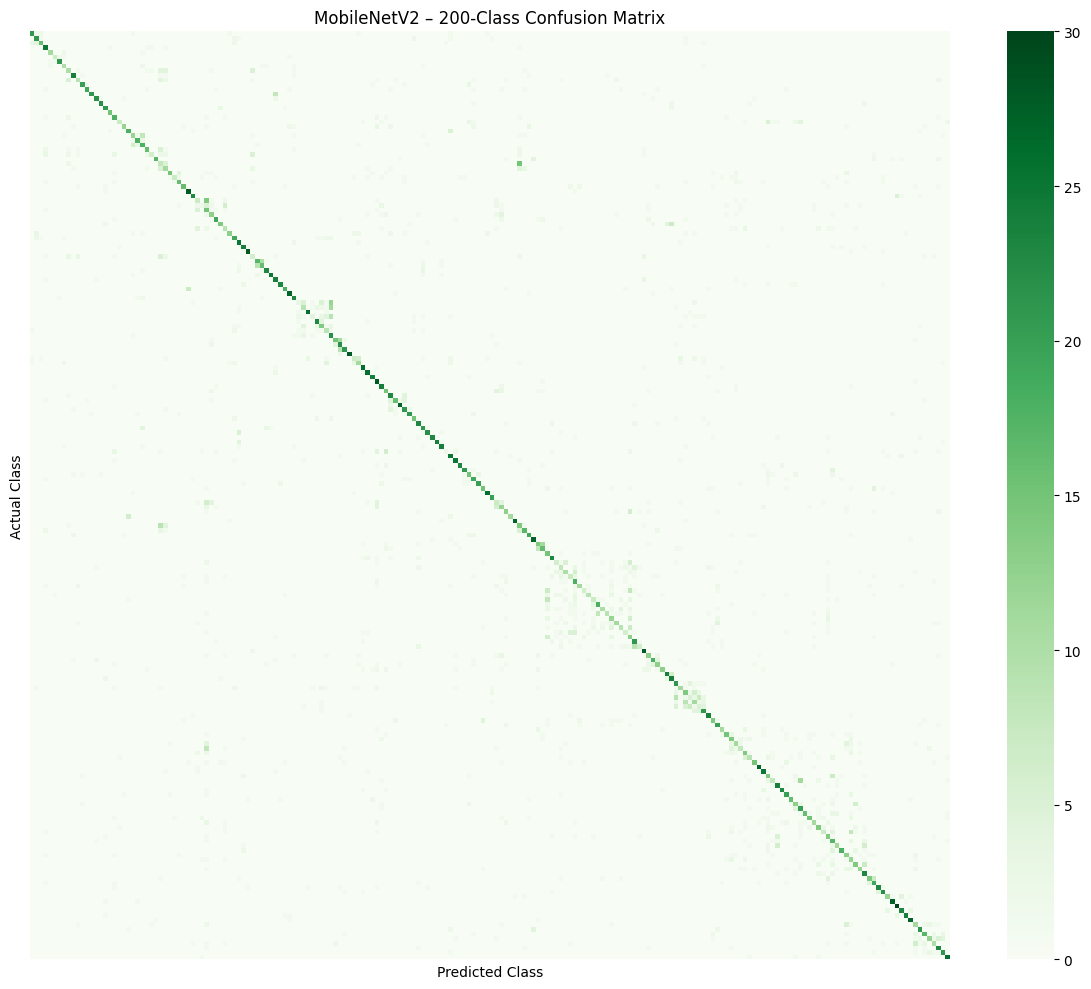

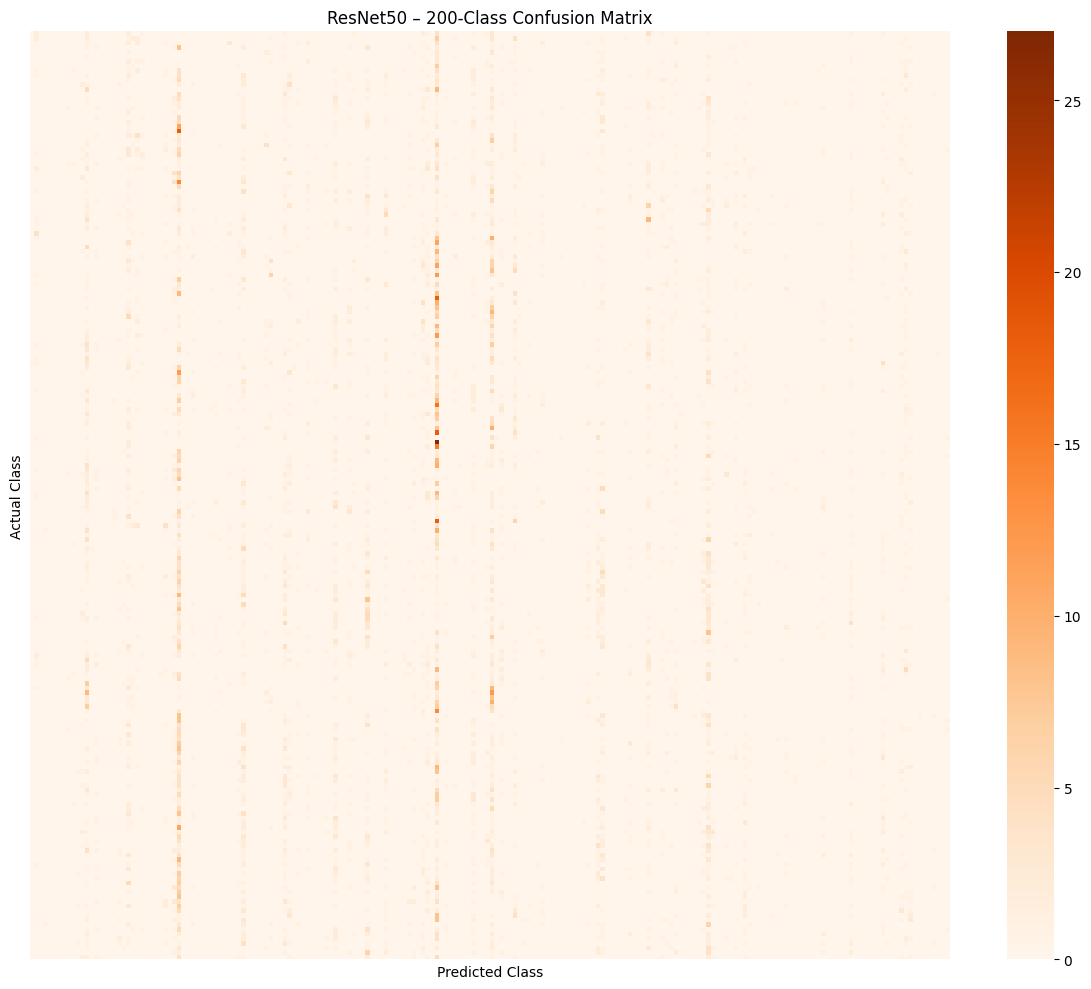

In [25]:
cms = [
    (y_true_cnn, y_pred_cnn, "Custom CNN", "Blues"),
    (y_true_mobilenet, y_pred_mobilenet, "MobileNetV2", "Greens"),
    (y_true_resnet, y_pred_resnet, "ResNet50", "Oranges")
]

for y_true, y_pred, name, cmap in cms:
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap=cmap, xticklabels=False, yticklabels=False)
    plt.title(f"{name} – 200-Class Confusion Matrix")
    plt.xlabel("Predicted Class"); plt.ylabel("Actual Class")
    plt.tight_layout(); plt.show()


## 3.3 Performance Metrics Summary


         Model  Accuracy  Precision  Recall  F1-Score
0   Custom CNN    0.1289     0.1337  0.1289    0.1099
1  MobileNetV2    0.5758     0.6019  0.5758    0.5719
2     ResNet50    0.0185     0.0104  0.0185    0.0082


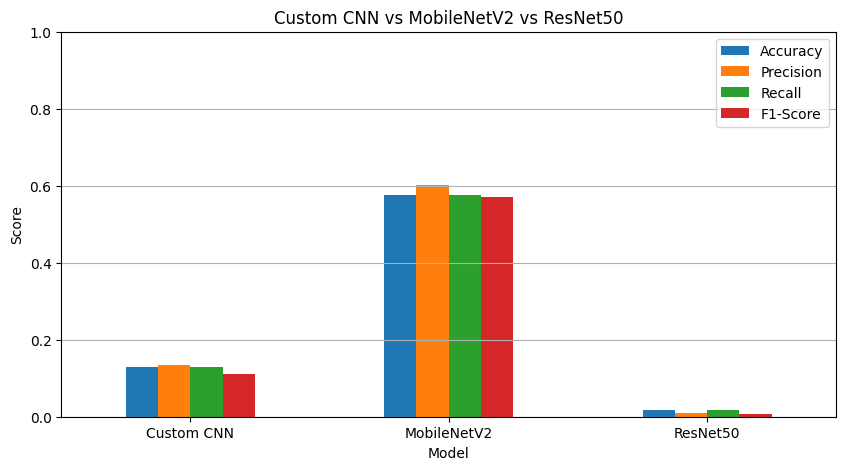

In [26]:
comparison_metrics = pd.DataFrame([cnn_results, mobilenet_results, resnet_results])
print(comparison_metrics.round(4))

comparison_metrics.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(10, 5))
plt.title("Custom CNN vs MobileNetV2 vs ResNet50")
plt.ylabel("Score"); plt.ylim(0, 1); plt.xticks(rotation=0); plt.grid(axis="y"); plt.show()


In [37]:
# FINAL MODEL PERFORMANCE COMPARISON

def get_metrics(model, results, history, test_ds):

    test_loss, _ = model.evaluate(test_ds, verbose=0)

    val_accuracy = max(history["val_accuracy"])
    val_loss = min(history["val_loss"])

    return {
        "Model": results["Model"],
        "Accuracy": f"{results['Accuracy'] * 100:.2f}%",
        "Precision": f"{results['Precision'] * 100:.2f}%",
        "Recall": f"{results['Recall'] * 100:.2f}%",
        "F1-Score": f"{results['F1-Score'] * 100:.2f}%",
        "Loss": f"{test_loss:.4f}",
        "Validation Loss": f"{val_loss:.4f}",
        "Validation Accuracy": f"{val_accuracy * 100:.2f}%",
        "Error": f"{(1 - results['Accuracy']) * 100:.2f}%"
    }


cnn_final = get_metrics(
    custom_cnn,
    cnn_results,
    history_cnn.history,
    test_ds
)

mobilenet_final = get_metrics(
    mobilenet_model,
    mobilenet_results,
    mobile_history,
    test_ds
)

resnet_final = get_metrics(
    resnet_model,
    resnet_results,
    resnet_history,
    test_ds
)

comparison_metrics = pd.DataFrame([
    cnn_final,
    mobilenet_final,
    resnet_final
])

print("\n" + "=" * 125)
print("FINAL MODEL PERFORMANCE COMPARISON")
print("=" * 125)
print(comparison_metrics.to_string(index=False))
print("=" * 125)


FINAL MODEL PERFORMANCE COMPARISON
      Model Accuracy Precision Recall F1-Score   Loss Validation Loss Validation Accuracy  Error
 Custom CNN   12.89%    13.37% 12.89%   10.99% 3.7995          3.7029              13.78% 87.11%
MobileNetV2   57.58%    60.19% 57.58%   57.19% 1.5031          1.5557              56.11% 42.42%
   ResNet50    1.85%     1.04%  1.85%    0.82% 5.1883          5.2164               2.00% 98.15%


## 3.4 Test Loss, Training Time and Parameter Comparison

These values are generated from the actual execution of the notebook.


In [27]:
summary = pd.DataFrame({
    "Metric": ["Test Accuracy (%)", "Test Loss", "Training Time (min)", "Total Parameters"],
    "Custom CNN": [cnn_results["Accuracy"]*100, cnn_test_loss, cnn_training_time/60, custom_cnn.count_params()],
    "MobileNetV2": [mobilenet_results["Accuracy"]*100, mobile_test_loss, (mobile_head_time+mobile_ft_time)/60, mobilenet_model.count_params()],
    "ResNet50": [resnet_results["Accuracy"]*100, resnet_test_loss, (resnet_head_time+resnet_ft_time)/60, resnet_model.count_params()]
})
print(summary)


                Metric    Custom CNN   MobileNetV2      ResNet50
0    Test Accuracy (%)  1.289265e+01  5.757680e+01  1.846738e+00
1            Test Loss  3.799532e+00  1.503122e+00  5.188347e+00
2  Training Time (min)  2.667176e+01  1.992042e+01  1.514024e+01
3     Total Parameters  1.293288e+06  2.637320e+06  2.416366e+07


## 3.5 Research Paper Reference Results

The supplied 2025 paper reports **74.60% MobileNet accuracy** and **0.8685 MobileNet loss**. These are published reference values, not results produced by this notebook. The paper also reports an InceptionV3 accuracy, but its abstract and Results section contain different values; this notebook does not use that inconsistent number as a target.

The paper states that its MobileNet/InceptionV3 comparison is based on CUB-200-2011 and discusses computational efficiency, with MobileNet positioned as a lightweight option for real-time/edge applications.


In [28]:
paper_reference = pd.DataFrame({
    "Reference Metric": ["Paper MobileNet Accuracy", "Paper MobileNet Loss"],
    "Published Value": [74.60, 0.8685]
})
print(paper_reference)


           Reference Metric  Published Value
0  Paper MobileNet Accuracy          74.6000
1      Paper MobileNet Loss           0.8685


## 3.6 Our MobileNetV2 vs Supplied Research Paper

This comparison is **methodological**, not an exact reproduction. The paper reports MobileNet, whereas this notebook uses MobileNetV2; training details, preprocessing implementation, split and software/hardware can also differ. Therefore, the comparison must not be interpreted as proof that one implementation reproduces the paper exactly.


              Metric  Our MobileNetV2  Paper MobileNet
0  Test Accuracy (%)        57.576804          74.6000
1          Test Loss         1.503122           0.8685


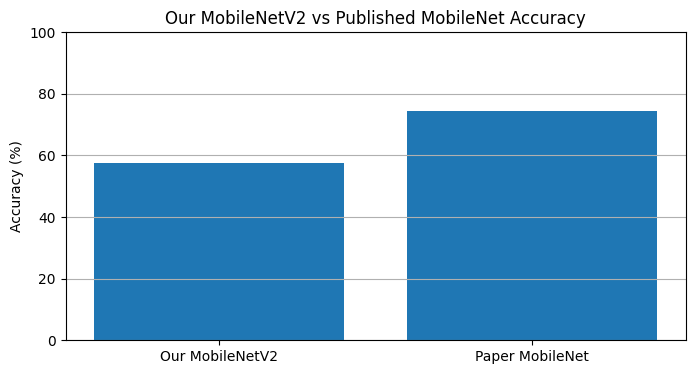

In [29]:
mobile_paper_comparison = pd.DataFrame({
    "Metric": ["Test Accuracy (%)", "Test Loss"],
    "Our MobileNetV2": [mobilenet_results["Accuracy"]*100, mobile_test_loss],
    "Paper MobileNet": [74.60, 0.8685]
})
print(mobile_paper_comparison)

plt.figure(figsize=(8, 4))
plt.bar(["Our MobileNetV2", "Paper MobileNet"], [mobilenet_results["Accuracy"]*100, 74.60])
plt.ylabel("Accuracy (%)"); plt.title("Our MobileNetV2 vs Published MobileNet Accuracy"); plt.ylim(0, 100); plt.grid(axis="y"); plt.show()


## 3.7 Model Analysis

### Custom CNN
The Custom CNN learns all features directly from the CUB dataset. It provides a useful baseline but does not benefit from ImageNet pretraining.

### MobileNetV2
MobileNetV2 provides a lightweight pretrained feature extractor and is suitable when computational efficiency and deployment constraints are important. This matches the research paper's motivation for using MobileNet-style architectures in wildlife applications.

### ResNet50
ResNet50 is deeper and generally more computationally demanding than MobileNetV2. Its residual architecture can capture strong hierarchical visual representations, but the additional complexity can increase training time and memory usage.

### Fair comparison
All three models use the same CUB split, image size, batch size, augmentation policy and final test set. The main architecture-specific difference is the pretrained backbone and its required preprocessing.


## 3.8 Potential Weaknesses

- CUB-200-2011 is a fine-grained problem with many visually similar species.
- Background, pose, lighting and occlusion can affect classification.
- ImageNet pretraining is not specific to birds.
- ResNet50 requires more computational resources than MobileNetV2.
- A single train/validation split can introduce variance.
- Fine-tuning can overfit when the target dataset is limited.
- Published-paper results and this implementation use different pipelines, so direct numerical equivalence should not be assumed.


## 3.9 Suggested Improvements

1. Compare MobileNet, MobileNetV2 and ResNet50 under the exact same training schedule.
2. Add Grad-CAM for explainable bird-species predictions.
3. Use class-balanced sampling if future datasets contain stronger imbalance.
4. Perform systematic hyperparameter search for learning rate, batch size and dropout.
5. Evaluate cross-dataset generalization using real field photographs.
6. Export the best lightweight model to TensorFlow Lite for edge deployment.
7. Investigate ensemble prediction from MobileNetV2 and ResNet50.
8. Compare inference time and memory consumption on CPU and edge hardware.


## 3.10 Result Visualization and Sample Prediction


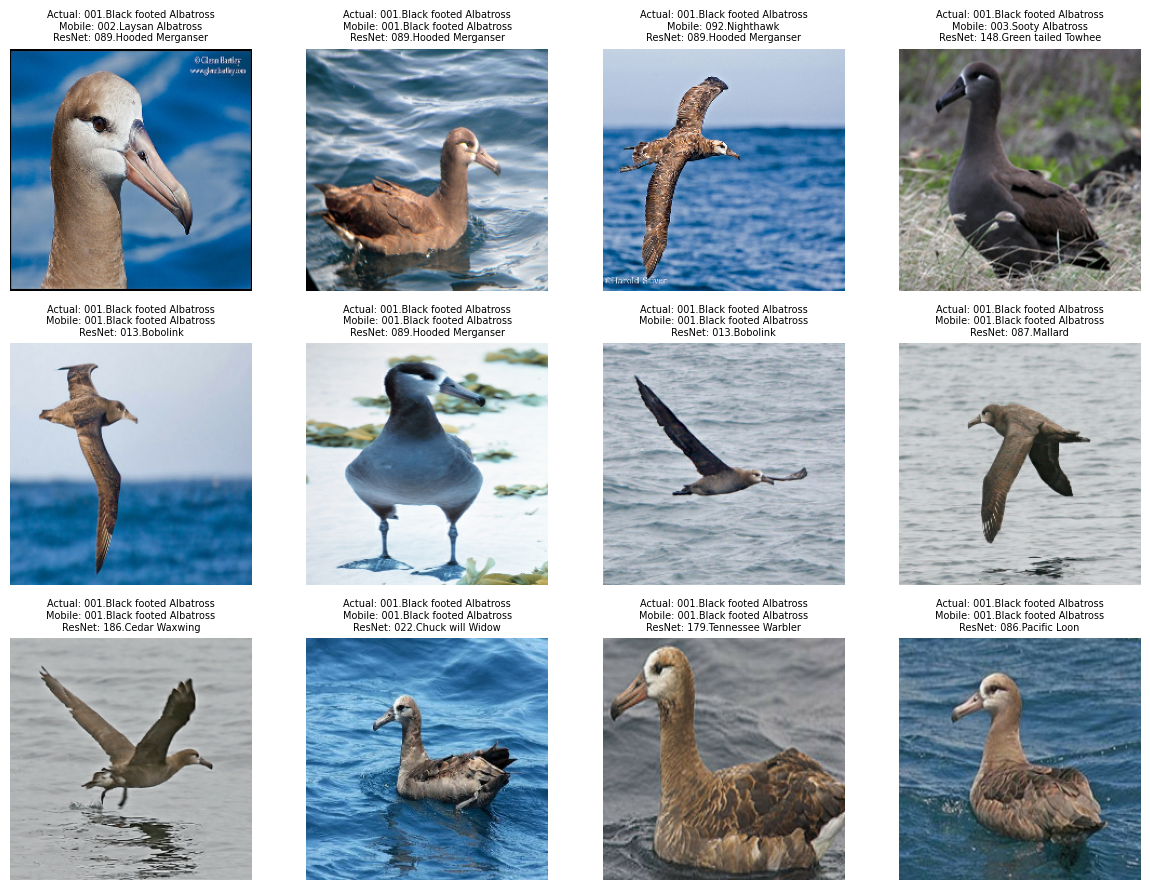

In [30]:
sample_images, sample_labels = next(iter(test_ds))
mobile_probs = mobilenet_model.predict(sample_images, verbose=0)
resnet_probs = resnet_model.predict(sample_images, verbose=0)
mobile_preds = np.argmax(mobile_probs, axis=1)
resnet_preds = np.argmax(resnet_probs, axis=1)

plt.figure(figsize=(12, 9))
for i in range(min(12, len(sample_images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(sample_images[i].numpy().astype("uint8"))
    actual = class_names[int(sample_labels[i].numpy())]
    mobile = class_names[int(mobile_preds[i])]
    resnet = class_names[int(resnet_preds[i])]
    plt.title(f"Actual: {actual}\nMobile: {mobile}\nResNet: {resnet}", fontsize=7)
    plt.axis("off")
plt.tight_layout(); plt.show()


# Conclusion

This practical implements a complete fine-grained bird-species image-classification pipeline using the CUB-200-2011 dataset. A Custom CNN is trained from scratch as a baseline, while MobileNetV2 and ResNet50 use ImageNet pretrained weights followed by transfer learning and controlled fine-tuning.

The notebook follows the main methodological ideas of the supplied research paper—preprocessing, augmentation, transfer learning, fine-tuning and multi-metric evaluation—while extending the comparison with ResNet50. The final accuracy, precision, recall, F1-score, loss, training time and parameter counts are generated from actual execution rather than manually entered values.

The supplied research paper reports 74.60% accuracy for its MobileNet experiment. This published value is retained only as a reference because the paper's model, training pipeline and reported experimental details are not identical to this MobileNetV2 implementation.


# References

1. S. Priya G., V. Saravanan K., and D. K., “Enhanced Bird Species Image Recognition and Classification using MobileNet and InceptionV3 Transfer learning Architectures,” *Electronic Letters on Computer Vision and Image Analysis*, vol. 24, no. 1, pp. 118–133, 2025. **Supplied research-paper PDF.**
2. CUB-200-2011 dataset: https://www.kaggle.com/datasets/wenewone/cub2002011?resource=download
3. K. He, X. Zhang, S. Ren, and J. Sun, “Deep Residual Learning for Image Recognition,” *CVPR*, 2016.
4. A. G. Howard et al., “MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications,” 2017.
5. The supplied project presentation, *Bird Species Image Classification Using Deep Learning – Comparative Study of Custom CNN and Transfer Learning*.


# Declaration

I, **Shreya Dattaram Bhosale**, confirm that the work submitted in this assignment is my own and has been completed according to academic-integrity guidelines. The research paper, dataset source and project reference materials are acknowledged above.

**Student Name:** Shreya Dattaram Bhosale  
**GitHub Repository Link:** ______________________________  
**Signature:** ______________________________
